# 06 · AML pattern analysis
Every rule below is an analytical indicator with a documented rationale, data requirement, exact logic, threshold and
threshold justification. Thresholds are development-period quantiles computed **without labels**; label overlap is
reported on held-out accounts in test weeks. None of these patterns establishes money laundering.

In [1]:
import sys, json, sqlite3
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import config
pd.set_option("display.width", 180); pd.set_option("display.max_columns", 30); pd.set_option("display.precision", 4)
T = lambda name: pd.read_csv(config.TABLES_DIR / f"{name}.csv")
KM = json.loads((config.TABLES_DIR / "key_metrics.json").read_text())
con = sqlite3.connect(config.DB_PATH)
def show(fig_name, width=11):
    img = plt.imread(config.FIGURES_DIR / f"{fig_name}.png")
    h, w = img.shape[:2]
    fig, ax = plt.subplots(figsize=(width, width * h / w)); ax.imshow(img); ax.axis("off")
print("outputs loaded from", config.TABLES_DIR.relative_to(ROOT))

outputs loaded from outputs/tables


In [2]:
rc = T("aml_rule_catalogue")
rc[["rule_id", "rule_name", "family", "data_required", "logic", "threshold_justification", "alerts_test",
    "pct_test_account_weeks", "label_precision_test", "lift_test", "in_framework"]]

,rule_id,rule_name,family,data_required,logic,threshold_justification,alerts_test,pct_test_account_weeks,label_precision_test,lift_test,in_framework
0,TXN-01,Large transaction,transaction,amount,max_amt >= 589.6,99% quantile of development-period transfer amounts (label-free),488,0.0159,0.1148,0.9512,True
1,VEL-01,High absolute velocity,velocity,"sender, receiver, step",n_tx >= 6,99% quantile of development account-weeks (label-free),342,0.0111,0.8421,6.9806,True
2,BEH-01,Velocity spike vs own baseline,behavioral,"sender, receiver, step (history)",velocity_ratio >= 3.273 and history exists,99% quantile of development account-weeks (label-free),212,0.0069,0.6321,5.2395,True
3,BEH-02,New-counterparty burst,behavioral,"sender, receiver, step (history)",new_cp >= 6,99% quantile of development account-weeks (label-free),171,0.0056,0.6842,5.6717,True
4,BEH-03,Amount escalation vs own baseline,behavioral,"amount, step (history)",amount_log_ratio >= 2.362,99% quantile of development account-weeks (label-free),153,0.0050,1.0000,8.2894,False
5,BEH-04,Dormant-account reactivation,behavioral,step (history),is_reactivated >= 1,binary flag,2068,0.0674,0.0662,0.5492,False
6,AML-01,Rapid pass-through,aml_pattern,"sender, receiver, amount, step",rapid_movement >= 0.8,99% quantile of development account-weeks (label-free),254,0.0083,0.2402,1.9908,True
7,AML-02,Repeated transfers to same receiver,aml_pattern,"sender, receiver, step",max_repeat_same_cp >= 2,structural definition (presence of the pattern),263,0.0086,1.0000,8.2894,False
8,AML-03,Circular flow,aml_pattern,"sender, receiver, step",cycle_count >= 1,structural definition (presence of the pattern),69,0.0022,0.4638,3.8444,True
9,NET-01,Fan-in collector,network,"sender, receiver, step",fan_in_28 >= 14,99% quantile of development account-weeks (label-free),270,0.0088,0.6333,5.2500,True


In [3]:
rc[["rule_id", "business_rationale", "limitations"]]

,rule_id,business_rationale,limitations
0,TXN-01,Largest single transfer this week is in the top 1% of all development-period transfer amounts.,"AMLSim caps amounts near 600, so 'large' has a narrow meaning; typology transfers are not larger."
1,VEL-01,Weekly transaction count in the top 1% of development account-weeks.,Absolute counts penalise legitimately busy accounts; simulation volume varies by week.
2,BEH-01,(this week's count + 1) / (historical weekly mean + 1) in the top 1%; account must have history.,Needs history; unstable for accounts with very few past transactions.
3,BEH-02,Number of counterparties never seen before this week in the top 1%.,"Almost every AMLSim background transfer goes to a new counterparty, so novelty is common."
4,BEH-03,"log(mean amount this week / historical median amount) in the top 1% (larger than usual). Requires >= 5 historical transactions. QUARANTINED: perfect development precision traced to artifact A1 (tiny typology amounts deflate the account's own baseline, so ordinary amounts look like escalation).",Partly driven by the sub-100 typology amounts (artifact A1) inflating/deflating baselines.
5,BEH-04,Activity after > 4 empty weeks. Evaluated but EXCLUDED: precision below the base rate in development.,Dormancy is mostly a simulator start/end effect here.
6,AML-01,"min(in/out balance of 28-day flows, share of outflow sent within 3 days of an inflow) in the top 1%.",Step granularity is one day; intra-day ordering of in/out flows is unknown.
7,AML-02,"Two or more transfers to the same receiver in one week (structuring-like). EXCLUDED from the framework: in AMLSim background activity never repeats a receiver within a week, so this rule's perfect precision is a simulator artifact, not transferable evidence.",Simulator artifact (A2/A3): background accounts never repeat a receiver within a week.
8,AML-03,Account lies on >= 1 time-respecting directed cycle (3-6 accounts) within 28 days.,Random background activity also forms time-respecting cycles; cycles are rare overall.
9,NET-01,Distinct senders over 28 days in the top 1% (many-to-one).,Legitimate collection accounts (e.g. merchants) would also trigger; no account-type field exists.


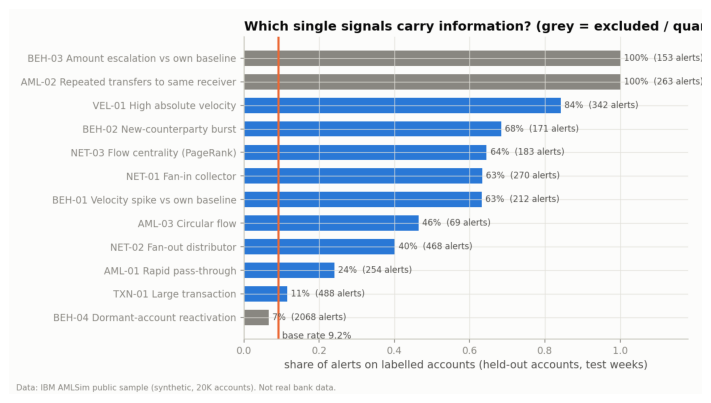

In [4]:
show("fig05_signal_precision", 10)

### Signal redundancy - do rules repeat each other?

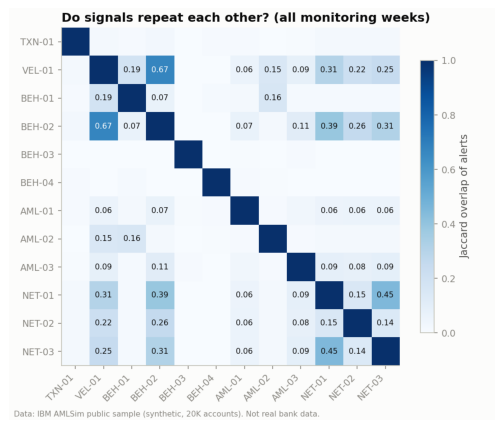

In [5]:
show("fig06_signal_overlap", 7)

### Structuring-style analysis (data-driven, no imported legal threshold)
AMLSim amounts are unit-less simulation values, so a real-world reporting threshold would be meaningless. We look for
repeated transfers to the same receiver within a week and for heaping just below round values.

In [6]:
T("structuring_summary")

,metric,value
0,sender-receiver-week groups with >=2 transfers,866.0000
1,share with near-identical amounts (CV < 5%),0.7263
2,share between two labelled accounts,1.0000
3,median transfers per group,5.0000
4,median amount per transfer,10.2300


In [7]:
T("amount_heaping_near_round_values")

,round_value,tx_in_5pct_below,tx_in_5pct_above,below_above_ratio
0,200,4411,2788,1.5821
1,300,3069,3558,0.8626
2,400,4649,2123,2.1898
3,500,2689,3139,0.8566
4,600,3514,0,NaN


### Simulator-artifact audit and quarantine rule

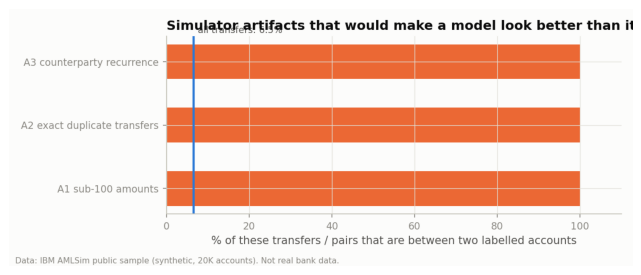

,artifact,observation,share_between_labelled_accounts,base_share,consequence
0,A1 sub-100 amounts,3695 transfers below 100,1.0,0.0654,Any amount rule tuned to small values would reproduce the label; not used.
1,A2 exact duplicate transfers,1684 extra identical copies,1.0,0.0654,Repeated-transfer rule AML-02 excluded from the framework.
2,A3 counterparty recurrence,905 of 117326 directed pairs transact more than once,1.0,0.0654,Background relationships are one-off; models rewarding 'few new counterparties' exploit the simulator and would not transfer to real banking.
3,A3b recurring counterparty in an account-week (dev),labelled 0.0377 vs unlabelled 0.0003,NaN,NaN,Same artifact measured on monitoring features.


In [8]:
show("fig17_simulator_artifacts", 9)
T("artifact_audit")

In [9]:
T("artifact_quarantine")

,signal,dev_alerts,dev_precision,quarantine_flag,in_framework,consistent
0,TXN-01,1163,0.1350,False,True,True
1,VEL-01,1185,0.6582,False,True,True
2,BEH-01,691,0.4906,False,True,True
3,BEH-02,856,0.5269,False,True,True
4,BEH-03,251,1.0000,True,False,True
5,BEH-04,2360,0.0419,False,False,True
6,AML-01,792,0.1995,False,True,True
7,AML-02,307,1.0000,True,False,True
8,AML-03,297,0.5589,False,True,True
9,NET-01,834,0.5228,False,True,True
